# Initialization

In [31]:
# imports

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random
from pyvis.network import Network
from IPython.display import display

In [32]:
# refactored: replaced the project paths initialization into a separate code block
# renamed your base_path to DATA_DIR_PATH as it was not clear by the name what it was leading to
# for the future, base is mostly associated with the root folder, you need to explicitly state what the path is leading to

# making sure the directory exists and if it doesn't then creating it under the specified path to avoid errors in the future

DATA_DIR_PATH = Path("data")
DATA_DIR_PATH.mkdir(parents=True, exist_ok=True)

RAW_DATA_DIR_PATH = DATA_DIR_PATH / "raw"
RAW_DATA_DIR_PATH.mkdir(parents=True, exist_ok=True)

DERIVED_DATA_DIR_PATH = DATA_DIR_PATH / "derived"
DERIVED_DATA_DIR_PATH.mkdir(parents=True, exist_ok=True)

In [33]:
random.seed(67)
np.random.seed(67)

# refactored: moved column cleaning into a reusable function that takes input_path and output_path
# now the function reads the original CSV, cleans the column names, and saves a cleaned copy separately
# this way we keep the raw data unchanged and store the derived version in the output path
# it still returns the pandas dataframe if needed
def clean_columns(input_path: Path, output_path: Path, save: bool = True):
    data = pd.read_csv(input_path)

    cleaned_columns = []
    for col in data.columns:
        col = col.replace("#", "")
        col = col.strip()
        cleaned_columns.append(col)

    data.columns = cleaned_columns

    if save:
        data.to_csv(output_path, index=False)

    return data

nodes = clean_columns(
    input_path = RAW_DATA_DIR_PATH / "nodes.csv",
    output_path = DERIVED_DATA_DIR_PATH / "nodes.csv"
)
edges = clean_columns(
    input_path = RAW_DATA_DIR_PATH / "edges.csv",
    output_path = DERIVED_DATA_DIR_PATH / "edges.csv"
)

# refactored: you were calling nodes/edges.head, forgot to add () in the end.
# also instead of print, since we work in a Jupyter notebook, use display() as it looks more organized
display(nodes.head())
display(edges.head())

,index,name
0,0,Aemon
1,1,Grenn
2,2,Samwell
3,3,Aerys
4,4,Jaime


,source,target,weight
0,0,1,5
1,0,2,31
2,2,82,6
3,2,58,34
4,2,76,12


# helper methods

In [34]:
# refactored: when naming functions, its better to use get_(...) when returning an object, for example a file or in case of lcc a subgraph. get_ postfix subconsciously makes a user/dev expect to "get" something from the function.

# when calculating a number or a certain statistical aspect, its better to use compute_ or calculate_ as its more self-explanatory

# making the function super short is not always the best approach, your task is to make the function as readable as possible, so when ur colleague reads it they can immediately understand what its doing without the need to visually decrypt ur code
# thats also why is not a very good idea to shorten names of the function as the name has to be self-explanatory and specific

def compute_graph_avg_degree(graph: nx.Graph):
    # for undirected graphs, this method counts the total number of edges in the graph
    number_of_edges = graph.number_of_edges()
    number_of_nodes = graph.number_of_nodes()

    # <k> = 2L / N
    average_degree = 2*number_of_edges / number_of_nodes

    return average_degree

def compute_graph_density(graph: nx.Graph):
    average_degree = compute_graph_avg_degree(graph)
    number_of_nodes = graph.number_of_nodes()

    # D = <k> / (n - 1)
    graph_density = average_degree / (number_of_nodes - 1)
    return graph_density

# refactored: overall was very good, we need to keep it readable, so I kept the logic, just split it
# also added a boolean "return_subgraph"
def detect_largest_connected_component_in_graph(graph: nx.Graph, return_subgraph:bool = True):
    components = nx.connected_components(graph)

    if graph.number_of_nodes() == 0:
        return None

    largest_connected_component = max(components, key=len)

    if return_subgraph:
        return graph.subgraph(largest_connected_component).copy()

    return largest_connected_component

# refactored: if in our helper function we have graph as input, then it should be like this everywhere
# this way is going to be a little bit more intuitive

''' REDUNDANT
def get_max_possible_edges_number(num_nodes):
    return (num_nodes*(num_nodes-1))/2
'''

def compute_max_possible_edges_from_node_count(node_count: int):
    # n*(n-1)/2
    return node_count * (node_count - 1) // 2 # making sure its not a float

def compute_graph_max_possible_edges(graph: nx.Graph):
    n = graph.number_of_nodes()
    max_possible_edges_number = compute_max_possible_edges_from_node_count(n)
    return max_possible_edges_number


# Week 1

explanation

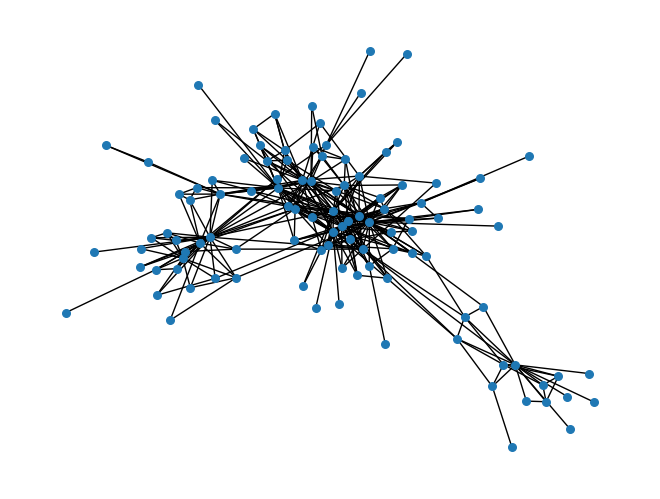

Number of Self Loops: 0


In [27]:
# graphing our data

G = nx.Graph()

# refactored: try to treat code blocks as separate "files", if ur using "nodes", then call/define it again, its not a big deal (performance-wise) but it makes it clear what exactly "nodes" are and what data-type you are using
nodes = pd.read_csv(DERIVED_DATA_DIR_PATH / "nodes.csv")
edges = pd.read_csv(DERIVED_DATA_DIR_PATH / "edges.csv")

# storing names under attribute called name for each node
for i in range(len(nodes)):
    idx = nodes["index"][i]
    name = nodes["name"][i]
    G.add_node(idx, name = name)

weighted_edge_list = list(zip(edges["source"], edges["target"], edges["weight"]))
G.add_weighted_edges_from(weighted_edge_list)

position = nx.spring_layout(G, seed=67) # kys

nx.draw(G, pos=position, node_size=30)

plt.show()

print(f"Number of Self Loops: {nx.number_of_selfloops(G)}")

In [19]:
# showing number of nodes and edges
print(f"Total Number of Nodes:   {G.number_of_nodes()}")
print(f"Total Number of Edges:   {G.number_of_edges()}")
print(f"Average Degree of Graph: {round(compute_graph_avg_degree(G), 2)}")
print(f"Density of Graph:        {round(compute_graph_density(G), 2)}")

"""
This graph has a pretty low density. Only 6% of possible connections are there.
Each node is roughly connected to 6 or 7 others.
"""

Total Number of Nodes:   107
Total Number of Edges:   352
Average Degree of Graph: 6.58
Density of Graph:        0.06


'\nThis graph has a pretty low density. Only 6% of possible connections are there.\nEach node is roughly connected to 6 or 7 others.\n'

# Week 2

explanation

In [22]:
# refactored: naming naming naming (!!!)
# added documentation explaining what functions do

def compute_node_clustering_coefficient(graph: nx.Graph, target_node):
    """
    Calculates the local clustering coefficient of a node in an undirected graph.
    Checks how many edges exist between the node's neighbors
    and divides this number by the maximum possible number of edges between them
    :param graph: graph reference
    :param target_node: node we are computing for
    :return: How connected the neighbors of this node are to one another
    """
    
    neighbors = list(graph.neighbors(target_node))
    number_of_neighbors = len(neighbors)
    max_edges = compute_max_possible_edges_from_node_count(number_of_neighbors)

    if max_edges == 0:
        return 0

    edge_count = 0

    for i in range(number_of_neighbors):
        for j in range(i+1, number_of_neighbors):
            if graph.has_edge(neighbors[i], neighbors[j]):
                edge_count+=1

    return edge_count / max_edges

# returns a dataframe with columns "node" and "clustering_coeff"
def get_nodes_clustering_coefficient(graph):
    clustering_info = {}

    for node in graph.nodes():
        clustering_info[node] = compute_node_clustering_coefficient(graph, node)

    return pd.DataFrame({
        "node": clustering_info.keys(), "clustering_coefficient": clustering_info.values()
        })

def compute_graph_avg_clustering_coefficient(graph):
    """
    Calculates the average clustering coefficient of the graph.
    First, it calculates the local clustering coefficient for every node.
    Then takes the mean of all node-level clustering coefficients
    :param graph: graph reference
    :return: average clustering coefficient of the whole graph
    """

    clustering_df = get_nodes_clustering_coefficient(graph)
    # refactored: simplified, does the same, just cleaner
    return clustering_df["clustering_coefficient"].mean()

In [23]:
# running average clustering calculations with largest connected component

lcc = detect_largest_connected_component_in_graph(G)

print(f"My Function's Average Clusering of lcc:              {round(compute_graph_avg_clustering_coefficient(lcc), 4)}")
print(f"The Built in Function for Average Clustering of lcc: {round(nx.average_clustering(lcc), 4)}")
print(f"The Transitivity of lcc:                             {round(nx.transitivity(lcc), 4)}")

My Function's Average Clusering of lcc:              0.5514
The Built in Function for Average Clustering of lcc: 0.5514
The Transitivity of lcc:                             0.3287


# Week 3

explanation

In [24]:
# helper functions
# refactored: changed function name to better represent what it does and returns. Added a small documentation.

def compute_node_clustering_coefficient_cdf(clustering_df: pd.DataFrame, column_name: str):
    """
    Computes the cumulative distribution of a selected node-level metric
    :return: the x and y values needed to plot the cumulative distribution of a selected column
    """

    sorted_values = clustering_df[column_name].sort_values().to_numpy()
    cumulative_distribution_function = np.arange(1, len(sorted_values) + 1) / len(sorted_values)

    return sorted_values, cumulative_distribution_function

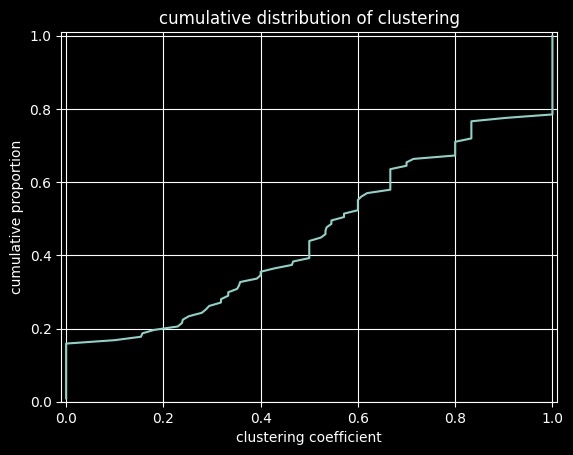

' \nThe intermediate distribution line is pretty smooth.\nThis indicates that the intermediate clusters are not concentrated at low or high values.\nIndicates that the network has a mix of nodes, some in weakly clustered neighborhoods while others in strongly clustered local groups.\nInitial Jump at 0 means that a noticable share of nodes have clustering coefficient equal or close to 0.\nThe large jump near 1 suggests that a large number of nodes have clustering coefficients close to 1, meaning their neighbors are highly connected.\n'

In [28]:
# Task 1 Cumulative Distribuiton of Clustering

# create a df with all clustering
clustering_df = get_nodes_clustering_coefficient(G)

cluster_x, cluster_y = compute_node_clustering_coefficient_cdf(clustering_df, "clustering_coefficient")

plt.plot(cluster_x, cluster_y)
plt.xlabel("clustering coefficient")
plt.ylabel("cumulative proportion")
plt.title("cumulative distribution of clustering")
plt.xlim(-0.01, 1.01)
plt.ylim(0, 1.01)
plt.grid(True)
plt.show()

''' 
The intermediate distribution line is pretty smooth.
This indicates that the intermediate clusters are not concentrated at low or high values.
Indicates that the network has a mix of nodes, some in weakly clustered neighborhoods while others in strongly clustered local groups.
Initial Jump at 0 means that a noticable share of nodes have clustering coefficient equal or close to 0.
The large jump near 1 suggests that a large number of nodes have clustering coefficients close to 1, meaning their neighbors are highly connected.
'''

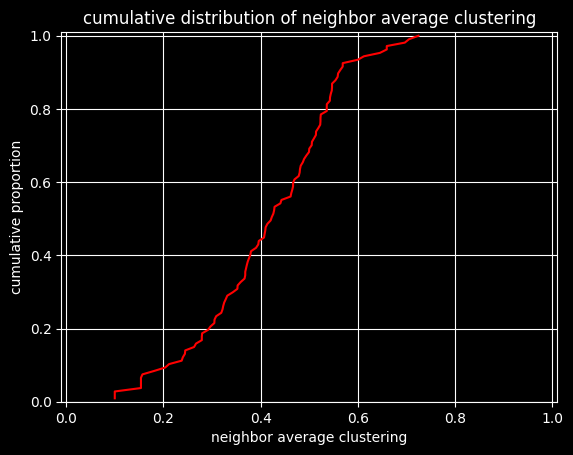

'\nThe average clustering of neighbors is concentrated in the middle range.\nThis makes since considering that we are taking the averages.\nThe curve rises steeply in the range of ~0.3-0.55. - This means many nodes have avg neighbor clustering in this range.\nIt shows that almost no nodes have average neighbors who are weakly or strongly clustered.\nThis shows that the local environments of nodes are pretty well balanced, more cohesive, and less clique-like.\n'

In [30]:
# Task 2 Average clustering of Neighbors

# converting clustering at every node df to dictionary for easier lookup
clustering_df = get_nodes_clustering_coefficient(G)
clustering_dict = dict(zip(clustering_df["node"], clustering_df["clustering_coefficient"]))

# building a dictionary containing each node and their average clustering of their neighbors
neighbor_avg_cluster = {}

for node in G.nodes():

    neighbors = list(G.neighbors(node))
    if len(neighbors) == 0:
        neighbor_avg_cluster[node] = 0
        continue

    total_cluster = 0
    count = 0

    for neighbor in neighbors:
        total_cluster += clustering_dict[neighbor]
        count += 1

    neighbor_avg_cluster[node] = total_cluster/count

neighbor_avg_cluster_df = pd.DataFrame({"node": neighbor_avg_cluster.keys(), "clustering_coefficient": neighbor_avg_cluster.values()})

neighbor_x, neighbor_y = compute_node_clustering_coefficient_cdf(neighbor_avg_cluster_df, "clustering_coefficient")

plt.plot(neighbor_x, neighbor_y, color = "red")
plt.xlabel("neighbor average clustering")
plt.ylabel("cumulative proportion")
plt.title("cumulative distribution of neighbor average clustering")
plt.xlim(-0.01, 1.01)
plt.ylim(0, 1.01)
plt.grid(True)
plt.show()

'''
The average clustering of neighbors is concentrated in the middle range.
This makes since considering that we are taking the averages.
The curve rises steeply in the range of ~0.3-0.55. - This means many nodes have avg neighbor clustering in this range.
It shows that almost no nodes have average neighbors who are weakly or strongly clustered.
This shows that the local environments of nodes are pretty well balanced, more cohesive, and less clique-like.
'''


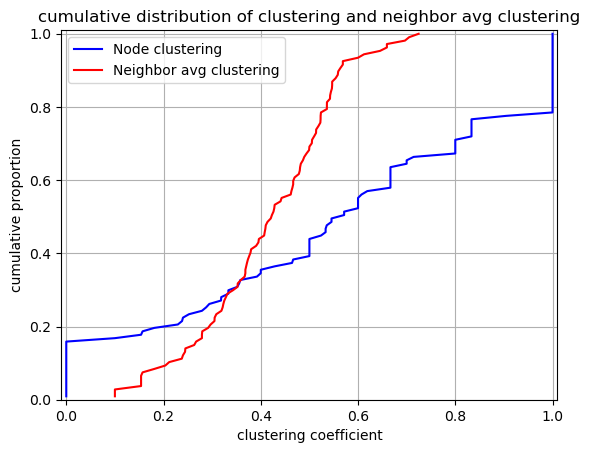

In [ ]:
# plotting both distirbution of nodes and neighbors on top of each other

plt.plot(cluster_x, cluster_y, color="blue", label="Node clustering")
plt.plot(neighbor_x, neighbor_y, color="red", label="Neighbor avg clustering")

plt.xlabel("clustering coefficient")
plt.ylabel("cumulative proportion")
plt.title("cumulative distribution of clustering and neighbor avg clustering")
plt.xlim(-0.01, 1.01)
plt.ylim(0, 1.01)
plt.grid(True)
plt.legend()
plt.show()

'''
Comparing the two distributions, the neighbor avg clustering is much more concentrated in the intermediate range.
The curve for node clustering is much more spread out. The red curve is below the blue one at low values suggesting
average clustering of neighbors smooths out extreme values for nodes.
'''

# Week 5

explain

In [ ]:
# week 5

# Week 6

explanation

In [ ]:
# week 6

# Week 7


explanation

In [ ]:
# week 7

# Week 9

explanation

In [ ]:
# week 9

# Week 10

explanation

In [ ]:
# week 10

# misc

In [114]:
def map_data():
    g = Network(height="15000px", width="100%",
                bgcolor="#222222", font_color="white")


# Introduction

intro

# Conclusion

conclusion